<a href="https://colab.research.google.com/github/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/blob/main/Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIM

To implement an Artificial Neural Network (ANN) to classify patients as having Chronic Kidney Disease (CKD) or not.

THEORY

Artificial Neural Network (ANN) is a supervised machine learning model inspired by the human brain. It consists of:

Input Layer - receives features
Hidden Layers - learn patterns
Output Layer - gives prediction

ANN uses:

Weights and biases
Activation functions (ReLU, Sigmoid)
Backpropagation for learning

It is well-suited for tabular medical datasets like CKD.

Step 1 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

Step 2 — Load Dataset

In [ ]:
url = "https://raw.githubusercontent.com/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/main/data/chronic_kidney_disease_full.csv"

data = pd.read_csv(url)
data.head()

,'age','bp','sg','al','su','rbc','pc','pcc','ba','bgr',...,'pcv','wbcc','rbcc','htn','dm','cad','appet','pe','ane','class'
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


Step 3 — Basic Preprocessing

In [ ]:
data.columns = data.columns.str.strip().str.replace("'", "")

# Separate types
num_cols = data.select_dtypes(include=['float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

# Fill numerical
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

# Fill categorical
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

Step 4 — Convert Categorical to Numeric

In [ ]:
le = LabelEncoder()

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

Step 5 — Fix Target Column

In [ ]:
data['class'] = data['class'].replace({2:1})

Step 6 — Separate Features & Target

In [ ]:
features = data.drop('class', axis=1)
target = data['class']

Step 7 — Feature Scaling

In [ ]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

Step 8 — Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.2, random_state=42
)

STEP 9 — BUILD ANN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential()

ann_model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 10 — Train Model

In [ ]:
history = ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.5938 - loss: 0.6674 - val_accuracy: 0.9375 - val_loss: 0.4964
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9570 - loss: 0.4122 - val_accuracy: 0.9844 - val_loss: 0.3221
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9727 - loss: 0.2700 - val_accuracy: 0.9688 - val_loss: 0.2233
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9766 - loss: 0.1869 - val_accuracy: 0.9531 - val_loss: 0.1670
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9766 - loss: 0.1383 - val_accuracy: 0.9688 - val_loss: 0.1305
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9883 - loss: 0.1061 - val_accuracy: 0.9688 - val_loss: 0.1024
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9922 - loss: 0.0852 - val_accuracy: 0.9688 - val_loss: 0.0819
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0582 - val_accuracy: 0.9688 - val_loss: 0.0682


Step 11 — Evaluate Model

In [ ]:
loss, accuracy = ann_model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9875 - loss: 0.0364 
Test Accuracy: 0.987500011920929


Step 12 — Predictions

In [ ]:
y_pred = (ann_model.predict(X_test) > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


Step 13 — Confusion Matrix

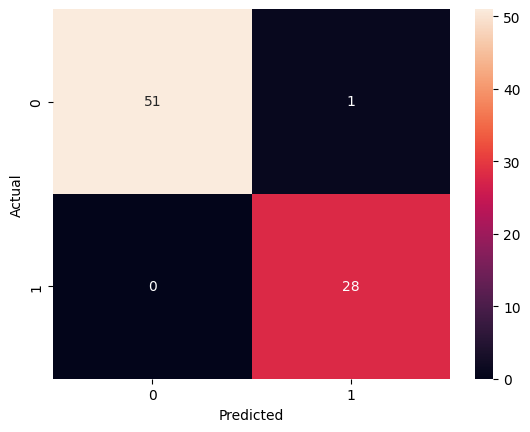

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Step 14 — Training Graph

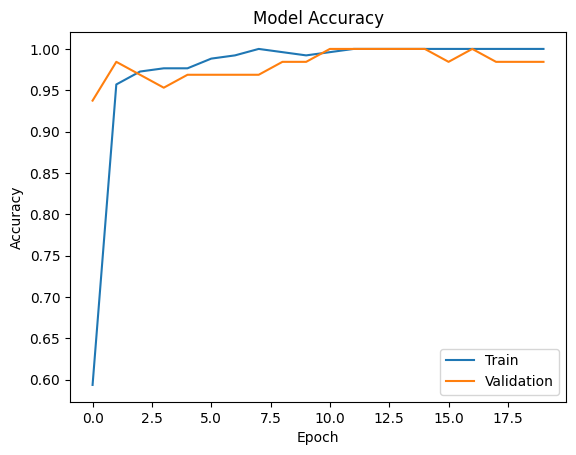

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

RESULT

The ANN model was successfully trained on the CKD dataset and achieved good classification accuracy on test data.

CONCLUSION

The ANN model demonstrated excellent performance on the CKD dataset with very high accuracy and strong generalization. The absence of false negatives makes it particularly suitable for medical applications where missing a disease case can be critical. However, further validation on larger datasets is recommended to ensure robustness.